# Stage 1 Segmentation Quality Upgrade Notebook

This notebook implements the Stage-1 improvements suggested by the latest diagnostics: cleaner masks, calibrated part presence, stronger false-positive suppression, support containment, boundary quality, and quality-aware HKG rebuilding.

The goal is not to change the HKG design first. The goal is to make Stage 1 produce better **terminal evidence** for the HKG: masks `M_k`, presence scores `p_k`, and part tokens `z_k`. Better terminals should produce cleaner prototypes and relation templates downstream.

Run order:

1. Configure paths and load data/model.
2. Evaluate the current Stage-1 checkpoint.
3. Fine-tune Stage 1 with the upgraded loss.
4. Re-evaluate and visualize individual part masks.
5. Rebuild HKG from the upgraded checkpoint.
6. Retrain Stage 2 and rerun the HKG diagnostics.


## 0. Environment and path setup

Edit `PROJECT_ROOT`, `PARTIMAGENET_ROOT`, and checkpoint paths. The notebook assumes it is placed under `notebooks/` in the project root.


In [1]:

from pathlib import Path
import os, sys, json, math, subprocess, textwrap

# If this notebook lives under notebooks/, this resolves the project root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# --------------------------- USER CONFIG ---------------------------
CONFIG_PATH = PROJECT_ROOT / "configs" / "stage1_quality_upgrade.yaml"
PARTIMAGENET_ROOT = Path("../../full_hyco/PartImageNet")  # <-- edit me

# Optional warm start from the previous Stage-1 checkpoint.
WARM_START_CKPT = PROJECT_ROOT / "runs" / "stage1" / "checkpoints" / "stage1_best.pt"

# Upgraded Stage-1 output checkpoint path.
UPGRADED_STAGE1_BEST = PROJECT_ROOT / "runs" / "stage1_quality_upgrade" / "checkpoints" / "stage1_quality_best.pt"

# HKG and Stage-2 output paths after using upgraded Stage 1.
UPGRADED_HKG_PATH = PROJECT_ROOT / "runs" / "stage1_quality_upgrade" / "checkpoints" / "aog_hkg_from_quality_stage1.pt"
UPGRADED_STAGE2_DIR = PROJECT_ROOT / "runs" / "stage2_aog_hkg_from_quality_stage1"

DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
MAX_EVAL_BATCHES = 12      # increase or set None for full validation
RUN_TRAIN = True          # set True to fine-tune Stage 1
RUN_HKG_REBUILD = False    # set True after training/evaluating upgraded Stage 1

FIG_DIR = PROJECT_ROOT / "notebooks" / "stage1_quality_upgrade_images"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("DEVICE:", DEVICE)


PROJECT_ROOT: /home/dfli/partcat_hkg_v3
CONFIG_PATH: /home/dfli/partcat_hkg_v3/configs/stage1_quality_upgrade.yaml
DEVICE: cuda


## 1. Imports and upgraded loss weights

The helper module is included in `src/partcat_hkg/training/stage1_quality_upgrade.py`. It is deliberately separate from the default training script so we can compare original and upgraded Stage 1 runs cleanly.


In [2]:

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from partcat_hkg.config import load_config
from partcat_hkg.data.loaders import make_datasets, make_loaders
from partcat_hkg.models.stage1 import PartCATHKGStage1
from partcat_hkg.utils.io import load_checkpoint, save_json
from partcat_hkg.utils.seed import set_seed
from partcat_hkg.training.stage1_quality_upgrade import (
    Stage1QualityLossWeights,
    evaluate_stage1_quality_detailed,
    train_stage1_quality_upgrade,
    summarize_stage1_quality_for_hkg,
    topmean_mask_probability,
)

cfg = load_config(CONFIG_PATH)
cfg.paths.partimagenet_root = str(PARTIMAGENET_ROOT)
set_seed(cfg.seed)

# Recommended extra losses. These can be tuned, but start with this conservative setting.
quality_weights = Stage1QualityLossWeights(
    presence_bce=0.40,
    # valid-but-absent parts are suppressed mildly; invalid parts are suppressed strongly.
    valid_absent_topmean_fp=0.08,
    valid_absent_mean_fp=0.02,
    invalid_part_topmean=0.35,
    invalid_part_mean=0.08,
    gt_support_leak=0.35,
    pred_support_containment=0.25,
    # small present parts get stronger shape losses.
    boundary=0.12,
    focal_functional=0.16,
    tversky_functional=0.18,
    small_part_area_tau=0.015,
    small_part_weight_max=6.0,
    small_part_weight_power=0.5,
    topq=0.02,
)
print(cfg)
print(quality_weights)


ProjectConfig(seed=123, run_name='stage1_quality_upgrade', paths=PathsConfig(partimagenet_root='../../full_hyco/PartImageNet', unseen_root='./auto_wnid_split_output/unseen_target_only', save_dir='runs/stage1_quality_upgrade', train_annotations='annotations/train/train.json', val_annotations='annotations/val/val.json', train_image_root='images/train', val_image_root='images/val'), data=DataConfig(img_size=320, num_workers=8, persistent_workers=True, prefetch_factor=4, max_train_samples=0, max_val_samples=0, use_stage2_image_only_loader=True), model=ModelConfig(stage1=Stage1Config(backbone_name='resnet18', model_dim=192, fuse_dim=128, token_dim=128, use_imagenet_backbone_pretrain=False, freeze_backbone=False, use_clip_text=True, clip_model_name='ViT-B-16', clip_pretrain_tag='laion2b_s34b_b88k', use_dino=True, dino_model_name='vit_small_patch16_224.dino', dino_input_size=224, dino_weights='', freeze_dino=True, use_cost_aggregation=True, cost_embed_dim=16, cost_agg_blocks=1, cost_agg_heads

## 2. Load datasets and verify schema

The train loader uses the original random augmentation. For evaluation and HKG building we disable train-time augmentation so geometry and relation templates are deterministic.


In [3]:

train_ds, val_ds = make_datasets(cfg)
stage1_train_loader, stage1_val_loader, _, _ = make_loaders(cfg, train_ds, val_ds)

schema = train_ds.schema
print(f"Schema: C={schema.num_classes}, K={schema.num_parts}, R={schema.num_roles}")
print("Classes:", schema.obj_names)
print("Parts:", schema.part_names)
print("Schema smoke:", schema.smoke_test(strict=False))

# Deterministic validation transform is already train=False. For HKG rebuilding later, also disable train augmentation.
if hasattr(train_ds, "transform"):
    print("Train transform train flag:", getattr(train_ds.transform, "train", None))


[dataset] train.json: 20457 samples | C=11 F=13 R=40
[dataset] val.json: 1205 samples | C=11 F=13 R=40
[datasets] train: ../../full_hyco/PartImageNet/annotations/train/train.json | images: ../../full_hyco/PartImageNet/images/train | samples: 20457
[datasets] val: ../../full_hyco/PartImageNet/annotations/val/val.json | images: ../../full_hyco/PartImageNet/images/val | samples: 1205
Schema: C=11, K=13, R=40
Classes: ['aeroplane', 'bicycle', 'biped', 'bird', 'boat', 'bottle', 'car', 'fish', 'quadruped', 'reptile', 'snake']
Parts: ['body', 'engine', 'fin', 'foot', 'hand', 'head', 'mirror', 'mouth', 'sail', 'seat', 'tail', 'wheel', 'wing']
Schema smoke: {'invalid_role_mappings': 0, 'duplicate_role_slots': 0}
Train transform train flag: True


## 3. Build Stage-1 model and optional warm start

The primary encoder is ResNet. DINO is optional frozen structural guidance, not the main encoder.


In [4]:

model = PartCATHKGStage1(schema, cfg.model.stage1).to(DEVICE)
print("Stage-1 status:")
print(json.dumps(model.status, indent=2))

if WARM_START_CKPT.exists():
    extra = load_checkpoint(WARM_START_CKPT, model, strict=False)
    print(f"Loaded warm-start checkpoint with strict=False for new high-res refine layers: {WARM_START_CKPT}")
    print("Checkpoint extra keys:", list(extra.keys()))
else:
    print(f"Warm-start checkpoint not found: {WARM_START_CKPT}")
    print("You can still train from scratch, but fine-tuning from the existing Stage-1 checkpoint is recommended.")

# quick tensor contract check
with torch.no_grad():
    shapes = model.smoke_forward(batch_size=1, image_size=min(128, cfg.data.img_size), device=DEVICE)
print(shapes)


/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened becau

Stage-1 status:
{
  "backbone": "resnet18",
  "backbone_fallback": false,
  "dino": "timm:vit_small_patch16_224.dino; input_resized_to=224",
  "text": "open_clip:ViT-B-16/laion2b_s34b_b88k; prompt_ensemble",
  "cost_aggregation": true,
  "spatial_aggregation": true,
  "part_aggregation": true,
  "token_pooling": {
    "temperature": 1.0,
    "alpha": 1.0,
    "presence_gated": true
  },
  "highres_refine": true
}
Warm-start checkpoint not found: /home/dfli/partcat_hkg_v3/runs/stage1/checkpoints/stage1_best.pt
You can still train from scratch, but fine-tuning from the existing Stage-1 checkpoint is recommended.
{'support_logits': (1, 1, 128, 128), 'part_logits': (1, 13, 128, 128), 'role_logits': (1, 40, 128, 128), 'obj_logits': (1, 11, 128, 128), 'part_presence': (1, 13), 'role_presence': (1, 40), 'part_tokens': (1, 13, 128), 'role_tokens': (1, 40, 128), 'func_agg': (1, 208, 8, 8)}


## 4. Evaluate current Stage 1 with quality diagnostics

This reports the usual loss plus the new failure-mode metrics: hallucination, miss, support leak, predicted-support containment, and per-part IoU. If this is run before training, it audits the warm-start checkpoint.


In [5]:
baseline_report = evaluate_stage1_quality_detailed(
    model, stage1_val_loader, cfg,
    device=DEVICE,
    max_batches=MAX_EVAL_BATCHES,
    loss_weights=quality_weights,
    mask_threshold=cfg.analysis.mask_bin_thr,
)
scalar_report = {k: v for k, v in baseline_report.items() if isinstance(v, (int, float))}
display(pd.DataFrame([scalar_report]).T.rename(columns={0: "baseline"}))

baseline_per_part = pd.DataFrame(baseline_report["per_part"])
baseline_per_class_part = pd.DataFrame(baseline_report.get("per_class_part", []))

# Important: iou_present is NaN when the part is never GT-present in this slice.
display(Markdown("### GT-present part localization: lowest IoU"))
display(baseline_per_part[baseline_per_part["present_count"] > 0].sort_values("iou_present").head(12))
display(Markdown("### Absent-part hallucination audit"))
display(baseline_per_part.sort_values("hallucination_rate", ascending=False).head(12))
if len(baseline_per_class_part):
    display(Markdown("### Per-class/per-part present localization"))
    display(baseline_per_class_part[baseline_per_class_part["present_count"] > 0].sort_values("iou_present").head(20))


,baseline
val_loss,8.379033
val_support,1.467430
val_func,1.972103
val_role,1.611276
val_invalid_role,1.110248
val_invalid_role_topk,1.893497
val_cons,0.286535
val_comp,1.590230
val_area,0.502643
val_cov,0.375004


### GT-present part localization: lowest IoU

,part_idx,part,iou,dice,iou_present,dice_present,iou_global_nonempty,dice_global_nonempty,presence_precision,presence_recall,presence_f1,hallucination_rate,miss_rate,present_count,union_nonempty_count,pred_area_mean,gt_area_mean,pred_topmean_mean,pred_presence_mean,pred_maxprob_mean
6,6,mirror,0.002273,0.004480,0.002273,0.004480,0.001690,0.003375,0.718750,1.0,0.836363,1.0,0.0,69.0,96.0,0.427268,0.002480,0.605951,0.658718,0.682945
11,11,wheel,0.043741,0.078261,0.043741,0.078261,0.040777,0.078358,0.947917,1.0,0.973262,1.0,0.0,91.0,96.0,0.486850,0.038063,0.653858,0.708867,0.739392
0,0,body,0.279144,0.412161,0.279144,0.412161,0.279144,0.436455,1.000000,1.0,0.999999,0.0,0.0,96.0,96.0,0.889361,0.279144,0.947824,0.956869,0.960767


### Absent-part hallucination audit

,part_idx,part,iou,dice,iou_present,dice_present,iou_global_nonempty,dice_global_nonempty,presence_precision,presence_recall,presence_f1,hallucination_rate,miss_rate,present_count,union_nonempty_count,pred_area_mean,gt_area_mean,pred_topmean_mean,pred_presence_mean,pred_maxprob_mean
1,1,engine,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.697378,0.000000,0.812113,0.844042,0.862051
3,3,foot,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.367293,0.000000,0.512185,0.563437,0.594666
2,2,fin,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.528838,0.000000,0.709290,0.758325,0.780134
4,4,hand,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.689335,0.000000,0.895201,0.924114,0.934582
5,5,head,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.616778,0.000000,0.813381,0.855440,0.873037
12,12,wing,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.664184,0.000000,0.815864,0.854996,0.871777
7,7,mouth,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.525467,0.000000,0.740574,0.779097,0.796493
8,8,sail,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.609282,0.000000,0.770580,0.818328,0.841937
9,9,seat,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.662239,0.000000,0.785595,0.822779,0.844186
10,10,tail,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.0,96.0,0.558618,0.000000,0.761581,0.811834,0.833858


### Per-class/per-part present localization

,class_idx,class,part_idx,part,present_count,iou_present,dice_present,presence_precision,presence_recall,presence_f1,hallucination_rate,miss_rate
6,6,car,6,mirror,69.0,0.002273,0.004480,0.718750,1.0,0.836363,1.0,0.0
11,6,car,11,wheel,91.0,0.043741,0.078261,0.947917,1.0,0.973262,1.0,0.0
0,6,car,0,body,96.0,0.279144,0.412161,1.000000,1.0,0.999999,0.0,0.0


## 5. Plot per-part Stage-1 failures

This plot tells us whether Stage 2/HKG is receiving trustworthy terminal part evidence. Large hallucination or miss rates usually produce noisy active HKG nodes and weak relation templates.


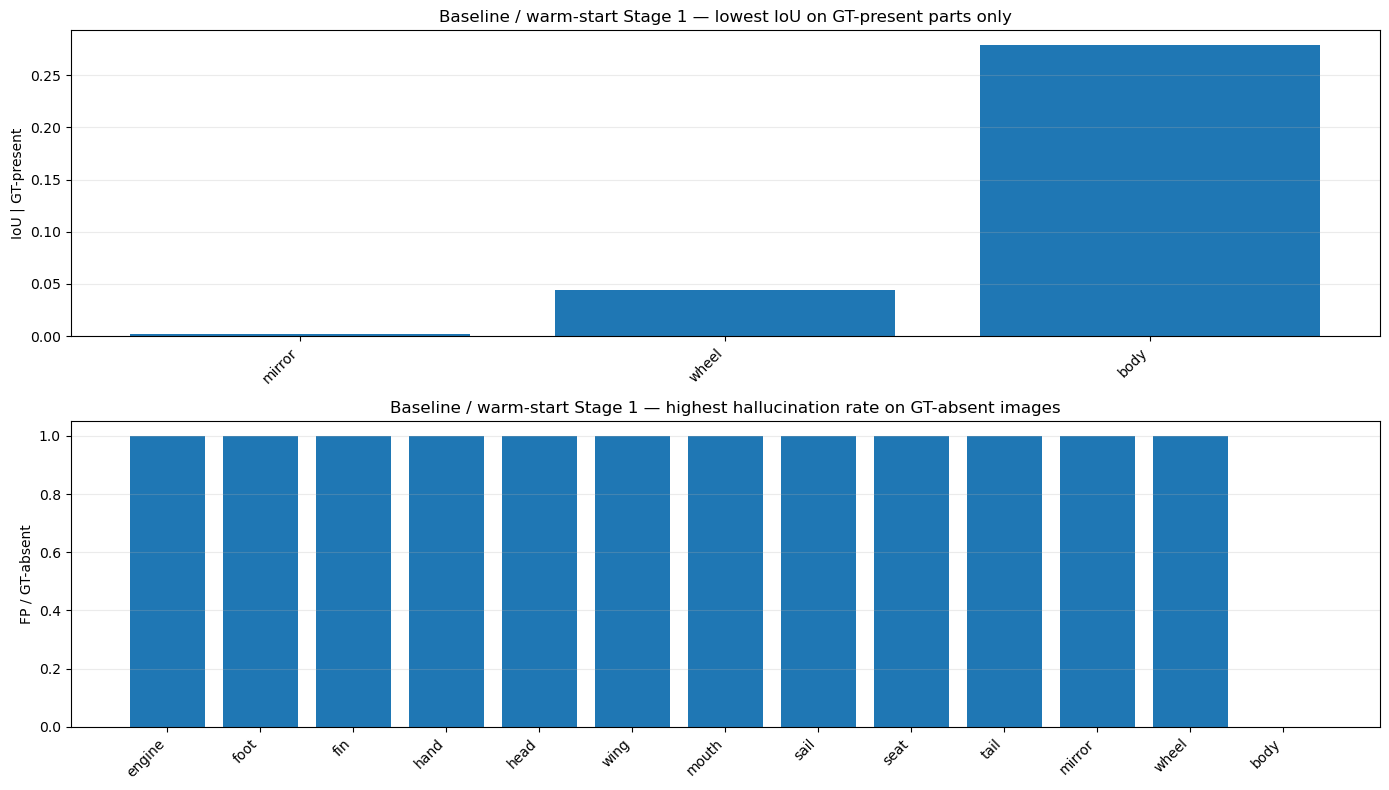

In [6]:
def plot_per_part_quality(per_part_df, title="Stage-1 per-part quality", out_path=None):
    df = per_part_df.copy()
    present_df = df[df["present_count"] > 0].sort_values("iou_present")
    n = min(len(df), 16)
    fig = plt.figure(figsize=(14, 8))
    ax1 = fig.add_subplot(2, 1, 1)
    worst = present_df.head(n)
    ax1.bar(np.arange(len(worst)), worst["iou_present"].values)
    ax1.set_title(title + " — lowest IoU on GT-present parts only")
    ax1.set_xticks(np.arange(len(worst)))
    ax1.set_xticklabels(worst["part"].values, rotation=45, ha="right")
    ax1.set_ylabel("IoU | GT-present")
    ax1.grid(axis="y", alpha=0.25)

    ax2 = fig.add_subplot(2, 1, 2)
    hall = per_part_df.sort_values("hallucination_rate", ascending=False).head(n)
    ax2.bar(np.arange(len(hall)), hall["hallucination_rate"].values)
    ax2.set_title(title + " — highest hallucination rate on GT-absent images")
    ax2.set_xticks(np.arange(len(hall)))
    ax2.set_xticklabels(hall["part"].values, rotation=45, ha="right")
    ax2.set_ylabel("FP / GT-absent")
    ax2.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
    return fig

fig = plot_per_part_quality(baseline_per_part, "Baseline / warm-start Stage 1", FIG_DIR / "baseline_stage1_per_part_quality.png")
plt.show()


## 6. Direct individual part-mask visualization

Union overlays can hide part collapse. This view shows each top predicted part separately, with GT mask, predicted mask, and overlap. It is the key visualization for deciding whether prototypes and relation templates will be contaminated.


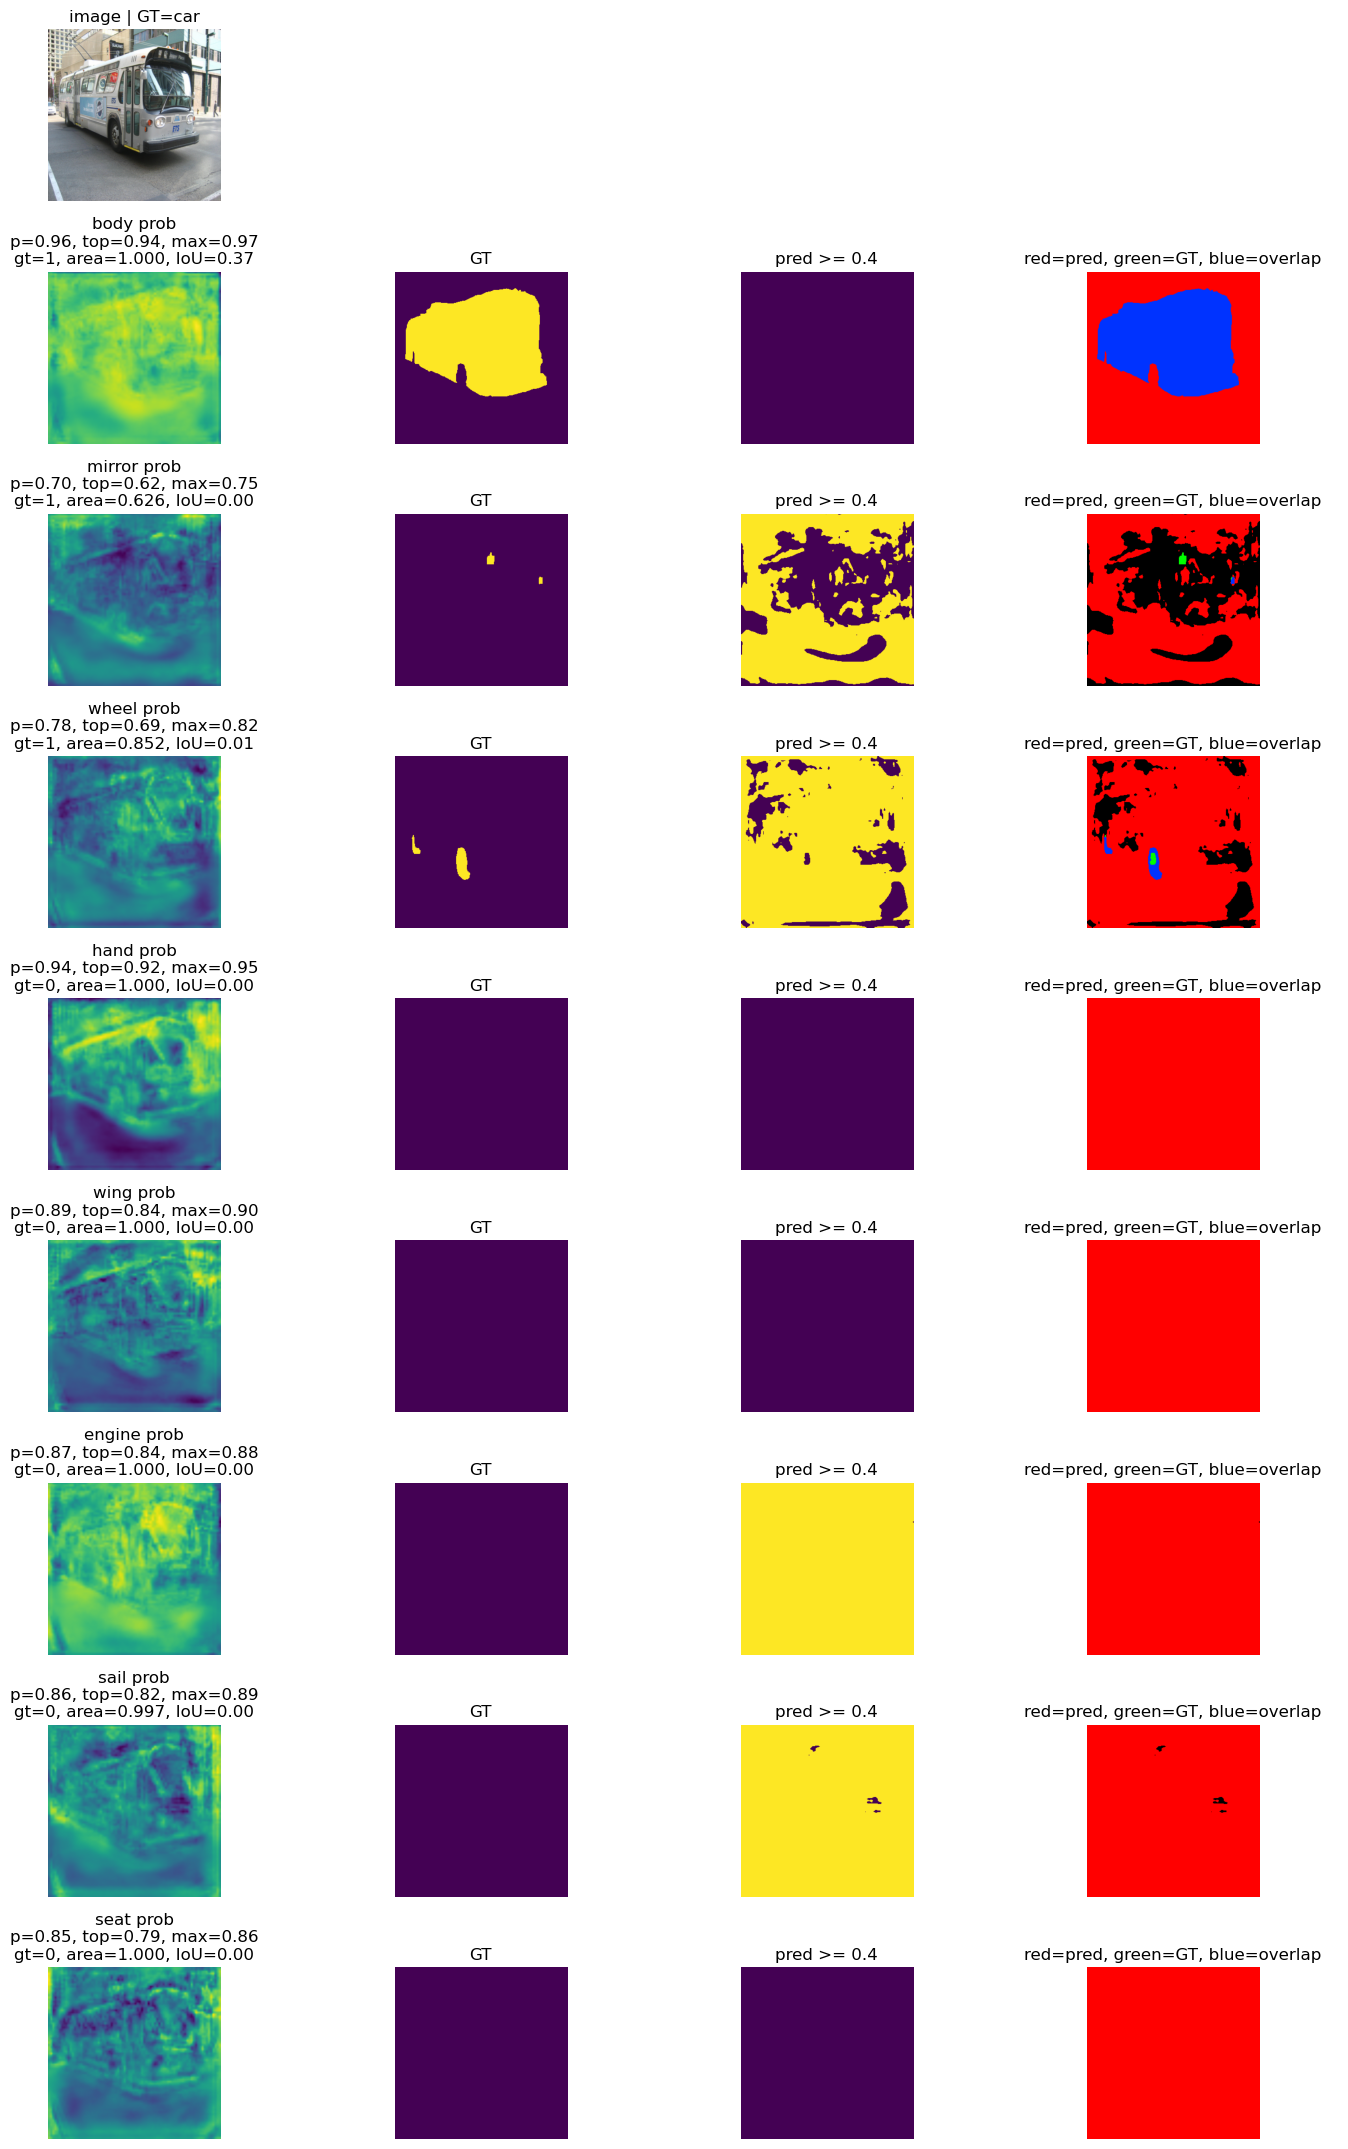

In [7]:
def _to_numpy_img(x):
    x = x.detach().cpu()
    if x.ndim == 3 and x.shape[0] in (1, 3):
        x = x.permute(1, 2, 0)
    x = x.float().numpy()
    x = np.clip(x, 0, 1)
    return x


def _part_order_for_visualization(pres, gt_pres, top_parts=8):
    # Always include GT-present parts first; otherwise small parts with low p are hidden.
    gt_order = torch.where(gt_pres > 0.5)[0].tolist()
    pred_order = torch.argsort(pres, descending=True).tolist()
    out = []
    for k in gt_order + pred_order:
        if k not in out:
            out.append(k)
        if len(out) >= top_parts:
            break
    return out


def _rgb_overlap(pred_bin, gt_bin):
    overlay = np.zeros((*gt_bin.shape, 3), dtype=np.float32)
    pred_only = pred_bin & ~gt_bin
    gt_only = gt_bin & ~pred_bin
    both = pred_bin & gt_bin
    overlay[pred_only] = [1.0, 0.0, 0.0]   # red
    overlay[gt_only] = [0.0, 1.0, 0.0]     # green
    overlay[both] = [0.0, 0.2, 1.0]        # blue
    return overlay

@torch.no_grad()
def visualize_individual_part_masks(model, batch, index=0, top_parts=8, thr=0.40, out_path=None):
    model.eval()
    image = batch["image"].to(DEVICE)
    out = model(image)
    raw = batch.get("image_raw", batch["image"])[index]
    img = _to_numpy_img(raw)
    prob = out["part_prob"][index].detach().cpu()
    gt = batch["part_masks"][index].detach().cpu()
    pres = out["part_presence"][index].detach().cpu()
    gt_pres = batch["presence"][index].detach().cpu()
    topmean = topmean_mask_probability(out["part_prob"].detach(), q=quality_weights.topq)[index].cpu()
    names = model.schema.part_names
    order = _part_order_for_visualization(pres, gt_pres, top_parts=top_parts)
    rows = len(order) + 1
    fig = plt.figure(figsize=(14, 2.4 * rows))
    ax = fig.add_subplot(rows, 4, 1)
    ax.imshow(img)
    ax.set_title(f"image | GT={batch['meta'][index].get('obj_name', '?')}")
    ax.axis("off")
    for j in range(2, 5):
        fig.add_subplot(rows, 4, j).axis("off")
    for r, k in enumerate(order, start=1):
        p = prob[k].numpy()
        g = gt[k].numpy() > 0.5
        pred_bin = p >= thr
        inter = pred_bin & g
        union = pred_bin | g
        iou = inter.sum() / union.sum() if union.sum() > 0 else float("nan")
        pred_area = pred_bin.mean()
        max_prob = float(prob[k].max().item())
        # columns: prob, GT, binary pred, overlap
        ax = fig.add_subplot(rows, 4, r * 4 + 1)
        ax.imshow(p)
        ax.set_title(
            f"{names[k]} prob\n"
            f"p={pres[k]:.2f}, top={topmean[k]:.2f}, max={max_prob:.2f}\n"
            f"gt={gt_pres[k]:.0f}, area={pred_area:.3f}, IoU={iou:.2f}"
        )
        ax.axis("off")
        ax = fig.add_subplot(rows, 4, r * 4 + 2)
        ax.imshow(g)
        ax.set_title("GT")
        ax.axis("off")
        ax = fig.add_subplot(rows, 4, r * 4 + 3)
        ax.imshow(pred_bin)
        ax.set_title(f"pred >= {thr}")
        ax.axis("off")
        ax = fig.add_subplot(rows, 4, r * 4 + 4)
        ax.imshow(_rgb_overlap(pred_bin, g))
        ax.set_title("red=pred, green=GT, blue=overlap")
        ax.axis("off")
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
    return fig

batch0 = next(iter(stage1_val_loader))
fig = visualize_individual_part_masks(model, batch0, index=0, top_parts=8, thr=cfg.analysis.mask_bin_thr, out_path=FIG_DIR / "baseline_individual_part_masks_sample0.png")
plt.show()


## 7. Fine-tune Stage 1 with the upgraded objective

Set `RUN_TRAIN=True` in the config cell to run this section. Checkpoints are saved as:

- `runs/stage1_quality_upgrade/checkpoints/stage1_quality_last.pt`
- `runs/stage1_quality_upgrade/checkpoints/stage1_quality_best.pt`

The model-selection score is deliberately not only loss: it rewards present-part mIoU and presence F1 and penalizes hallucination.


In [8]:

if RUN_TRAIN:
    history = train_stage1_quality_upgrade(
        model,
        stage1_train_loader,
        stage1_val_loader,
        cfg,
        device=DEVICE,
        loss_weights=quality_weights,
    )
    hist_df = pd.DataFrame(history)
    display(hist_df.tail())
else:
    print("RUN_TRAIN=False, skipping fine-tuning. Set RUN_TRAIN=True to train.")


[stage1-quality] epoch=1 train_loss=2.7824 val_mIoU=0.2423 presence_f1=0.7907 halluc=0.1352 score=0.4265
[stage1-quality] epoch=2 train_loss=2.4008 val_mIoU=0.3233 presence_f1=0.8369 halluc=0.1224 score=0.5203
[stage1-quality] epoch=3 train_loss=2.2923 val_mIoU=0.3420 presence_f1=0.8333 halluc=0.1229 score=0.5380
[stage1-quality] epoch=4 train_loss=2.2359 val_mIoU=0.3694 presence_f1=0.8316 halluc=0.1383 score=0.5634
[stage1-quality] epoch=5 train_loss=2.1918 val_mIoU=0.3818 presence_f1=0.8433 halluc=0.1222 score=0.5804
[stage1-quality] epoch=6 train_loss=2.1597 val_mIoU=0.3940 presence_f1=0.8495 halluc=0.1158 score=0.5948
[stage1-quality] epoch=7 train_loss=2.1304 val_mIoU=0.4054 presence_f1=0.8547 halluc=0.1238 score=0.6067
[stage1-quality] epoch=8 train_loss=2.0992 val_mIoU=0.4136 presence_f1=0.8306 halluc=0.1159 score=0.6096
[stage1-quality] epoch=9 train_loss=2.0740 val_mIoU=0.4185 presence_f1=0.8273 halluc=0.1231 score=0.6131
[stage1-quality] epoch=10 train_loss=2.0566 val_mIoU=0.

,train_loss,train_support,train_func,train_role,train_invalid_role,train_invalid_role_topk,train_cons,train_comp,train_area,train_cov,...,val_dice_global_nonempty,val_miou_present_parts,val_dice_present_parts,val_miou_all,val_dice_all,val_presence_precision_macro,val_presence_recall_macro,val_presence_f1_macro,val_hallucination_macro,val_miss_macro
19,1.904655,0.134459,0.941040,0.374815,0.001243,0.034928,0.001423,0.076465,0.020109,0.155726,...,0.648262,0.425826,0.523878,0.425826,0.523878,0.844655,0.845278,0.835831,0.102591,0.154722
20,1.894985,0.131301,0.940242,0.372737,0.001211,0.033008,0.001392,0.075826,0.019863,0.153798,...,0.662820,0.438419,0.537130,0.438419,0.537130,0.843645,0.874037,0.855677,0.112653,0.125963
21,1.883143,0.129544,0.939614,0.368467,0.001106,0.031729,0.001343,0.074538,0.019426,0.149924,...,0.664309,0.441006,0.540901,0.441006,0.540901,0.845603,0.869589,0.852981,0.117007,0.130411
22,1.871222,0.127831,0.938302,0.364241,0.001111,0.030450,0.001321,0.073636,0.019119,0.146333,...,0.660626,0.433792,0.532527,0.433792,0.532527,0.854482,0.855289,0.848032,0.107012,0.144711
23,1.865289,0.126977,0.938387,0.361805,0.000978,0.028949,0.001292,0.072715,0.018595,0.144501,...,0.658682,0.429761,0.526770,0.429761,0.526770,0.854706,0.856711,0.843825,0.110278,0.143289


## 8. Load upgraded checkpoint and compare to warm start

Run this after training. If the upgraded checkpoint does not exist, this cell keeps using the current model.


In [9]:

if UPGRADED_STAGE1_BEST.exists():
    load_checkpoint(UPGRADED_STAGE1_BEST, model, strict=False)
    print("Loaded upgraded Stage-1 checkpoint:", UPGRADED_STAGE1_BEST)
else:
    print("Upgraded checkpoint not found yet; evaluating the current in-memory model.")

upgraded_report = evaluate_stage1_quality_detailed(
    model, stage1_val_loader, cfg,
    device=DEVICE,
    max_batches=MAX_EVAL_BATCHES,
    loss_weights=quality_weights,
    mask_threshold=cfg.analysis.mask_bin_thr,
)
upgraded_scalars = {k: v for k, v in upgraded_report.items() if isinstance(v, (int, float))}
compare_df = pd.DataFrame([scalar_report, upgraded_scalars], index=["baseline", "upgraded"]).T
display(compare_df)

upgraded_per_part = pd.DataFrame(upgraded_report["per_part"])
upgraded_per_class_part = pd.DataFrame(upgraded_report.get("per_class_part", []))
part_compare = baseline_per_part.merge(upgraded_per_part, on=["part_idx", "part"], suffixes=("_base", "_upg"))
part_compare["delta_iou"] = part_compare["iou_present_upg"] - part_compare["iou_present_base"]
part_compare["delta_hallucination"] = part_compare["hallucination_rate_upg"] - part_compare["hallucination_rate_base"]
display(part_compare.sort_values("delta_iou", ascending=False).head(12))
display(part_compare.sort_values("delta_hallucination").head(12))


Upgraded checkpoint not found yet; evaluating the current in-memory model.


,baseline,upgraded
val_loss,8.379033,2.233895
val_support,1.467430,0.265034
val_func,1.972103,0.946895
val_role,1.611276,0.398696
val_invalid_role,1.110248,0.000507
val_invalid_role_topk,1.893497,0.020863
val_cons,0.286535,0.000682
val_comp,1.590230,0.156592
val_area,0.502643,0.015372
val_cov,0.375004,0.299618


,part_idx,part,iou_base,dice_base,iou_present_base,dice_present_base,iou_global_nonempty_base,dice_global_nonempty_base,presence_precision_base,presence_recall_base,...,miss_rate_upg,present_count_upg,union_nonempty_count_upg,pred_area_mean_upg,gt_area_mean_upg,pred_topmean_mean_upg,pred_presence_mean_upg,pred_maxprob_mean_upg,delta_iou,delta_hallucination
11,11,wheel,0.043741,0.078261,0.043741,0.078261,0.040777,0.078358,0.947917,1.0,...,0.010989,91.0,94.0,0.037898,0.038063,0.777290,0.954246,0.964668,0.625563,-0.400000
0,0,body,0.279144,0.412161,0.279144,0.412161,0.279144,0.436455,1.000000,1.0,...,0.000000,96.0,96.0,0.279229,0.279144,0.988138,0.994922,0.997388,0.540960,0.000000
6,6,mirror,0.002273,0.004480,0.002273,0.004480,0.001690,0.003375,0.718750,1.0,...,0.347826,69.0,76.0,0.001322,0.002480,0.065013,0.453470,0.625274,0.214834,-0.851852
1,1,engine,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,1.0,0.000030,0.000000,0.001037,0.005169,0.009114,NaN,-0.989583
2,2,fin,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000010,0.000000,0.000142,0.000784,0.003648,NaN,-1.000000
3,3,foot,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000016,0.000000,0.000238,0.000726,0.001432,NaN,-1.000000
4,4,hand,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000061,0.000000,0.000489,0.001041,0.002029,NaN,-1.000000
5,5,head,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,2.0,0.000028,0.000000,0.001040,0.006033,0.021430,NaN,-0.989583
7,7,mouth,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000005,0.000000,0.000047,0.000154,0.000430,NaN,-1.000000
8,8,sail,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000040,0.000000,0.000463,0.001241,0.002227,NaN,-1.000000


,part_idx,part,iou_base,dice_base,iou_present_base,dice_present_base,iou_global_nonempty_base,dice_global_nonempty_base,presence_precision_base,presence_recall_base,...,miss_rate_upg,present_count_upg,union_nonempty_count_upg,pred_area_mean_upg,gt_area_mean_upg,pred_topmean_mean_upg,pred_presence_mean_upg,pred_maxprob_mean_upg,delta_iou,delta_hallucination
3,3,foot,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000016,0.000000,0.000238,0.000726,0.001432,NaN,-1.000000
2,2,fin,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000010,0.000000,0.000142,0.000784,0.003648,NaN,-1.000000
7,7,mouth,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000005,0.000000,0.000047,0.000154,0.000430,NaN,-1.000000
4,4,hand,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000061,0.000000,0.000489,0.001041,0.002029,NaN,-1.000000
12,12,wing,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000023,0.000000,0.000317,0.001077,0.001946,NaN,-1.000000
10,10,tail,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000010,0.000000,0.000211,0.001147,0.004447,NaN,-1.000000
9,9,seat,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,1.0,0.000005,0.000000,0.000112,0.001112,0.009869,NaN,-1.000000
8,8,sail,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.000040,0.000000,0.000463,0.001241,0.002227,NaN,-1.000000
1,1,engine,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,1.0,0.000030,0.000000,0.001037,0.005169,0.009114,NaN,-0.989583
5,5,head,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,...,0.000000,0.0,2.0,0.000028,0.000000,0.001040,0.006033,0.021430,NaN,-0.989583


## 9. Plot upgraded-vs-baseline changes

The desired outcome is higher IoU/F1 and lower hallucination/support leak. If mIoU improves but hallucination rises, increase `absent_topmean_fp`, `invalid_part_topmean`, or the presence threshold.


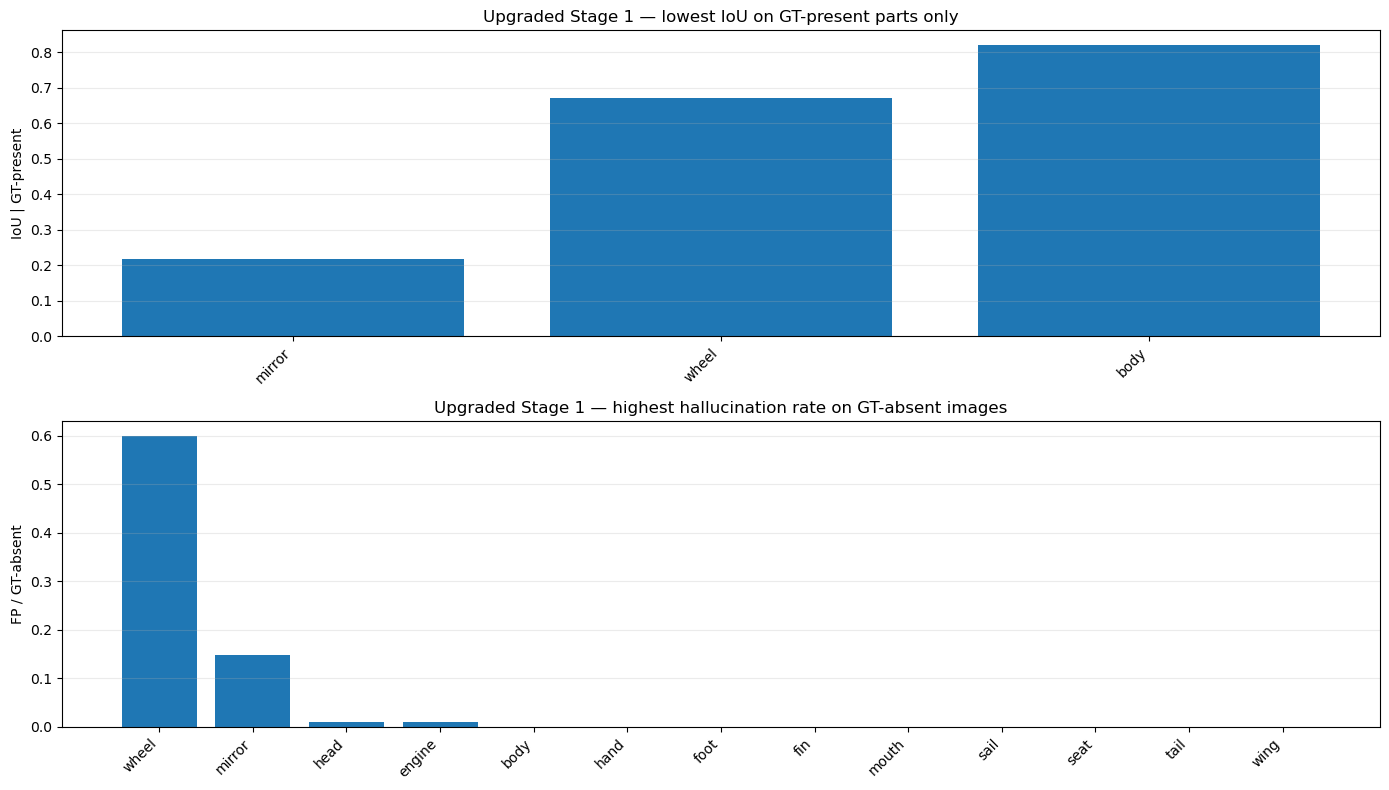

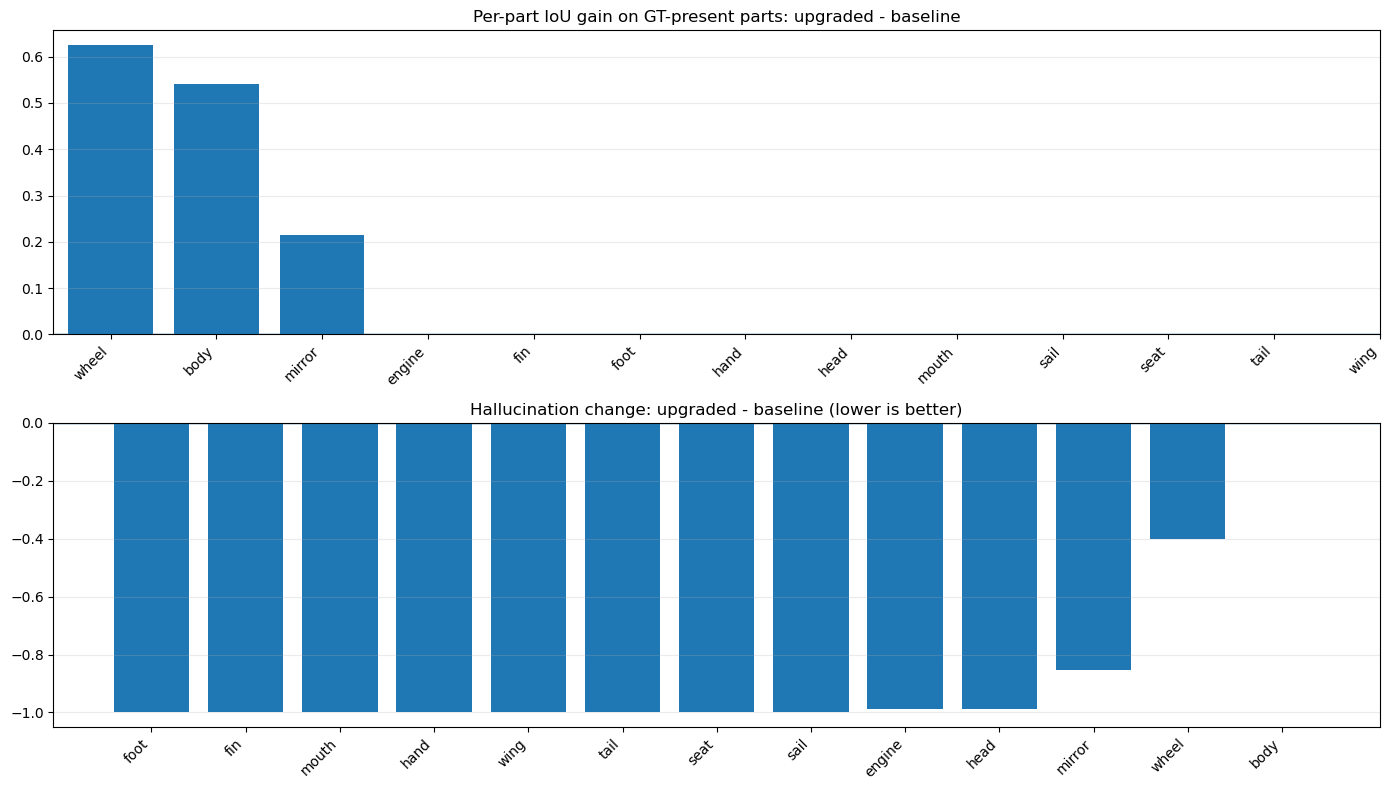

In [10]:

def plot_upgrade_deltas(part_compare, out_path=None):
    df = part_compare.copy().sort_values("delta_iou", ascending=False)
    n = min(len(df), 18)
    fig = plt.figure(figsize=(14, 8))
    ax1 = fig.add_subplot(2, 1, 1)
    top = df.head(n)
    ax1.bar(np.arange(n), top["delta_iou"].values)
    ax1.set_title("Per-part IoU gain on GT-present parts: upgraded - baseline")
    ax1.set_xticks(np.arange(n))
    ax1.set_xticklabels(top["part"].values, rotation=45, ha="right")
    ax1.axhline(0.0, linewidth=1)
    ax1.grid(axis="y", alpha=0.25)

    ax2 = fig.add_subplot(2, 1, 2)
    hall = part_compare.sort_values("delta_hallucination").head(n)
    ax2.bar(np.arange(n), hall["delta_hallucination"].values)
    ax2.set_title("Hallucination change: upgraded - baseline (lower is better)")
    ax2.set_xticks(np.arange(n))
    ax2.set_xticklabels(hall["part"].values, rotation=45, ha="right")
    ax2.axhline(0.0, linewidth=1)
    ax2.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
    return fig

fig = plot_per_part_quality(upgraded_per_part, "Upgraded Stage 1", FIG_DIR / "upgraded_stage1_per_part_quality.png")
plt.show()
fig = plot_upgrade_deltas(part_compare, FIG_DIR / "stage1_upgrade_delta_quality.png")
plt.show()


## 10. Visualize upgraded individual masks

Compare this figure to the earlier baseline individual-mask view. The important improvements are fewer wrong high-presence parts, less leakage outside object support, and clearer small parts.


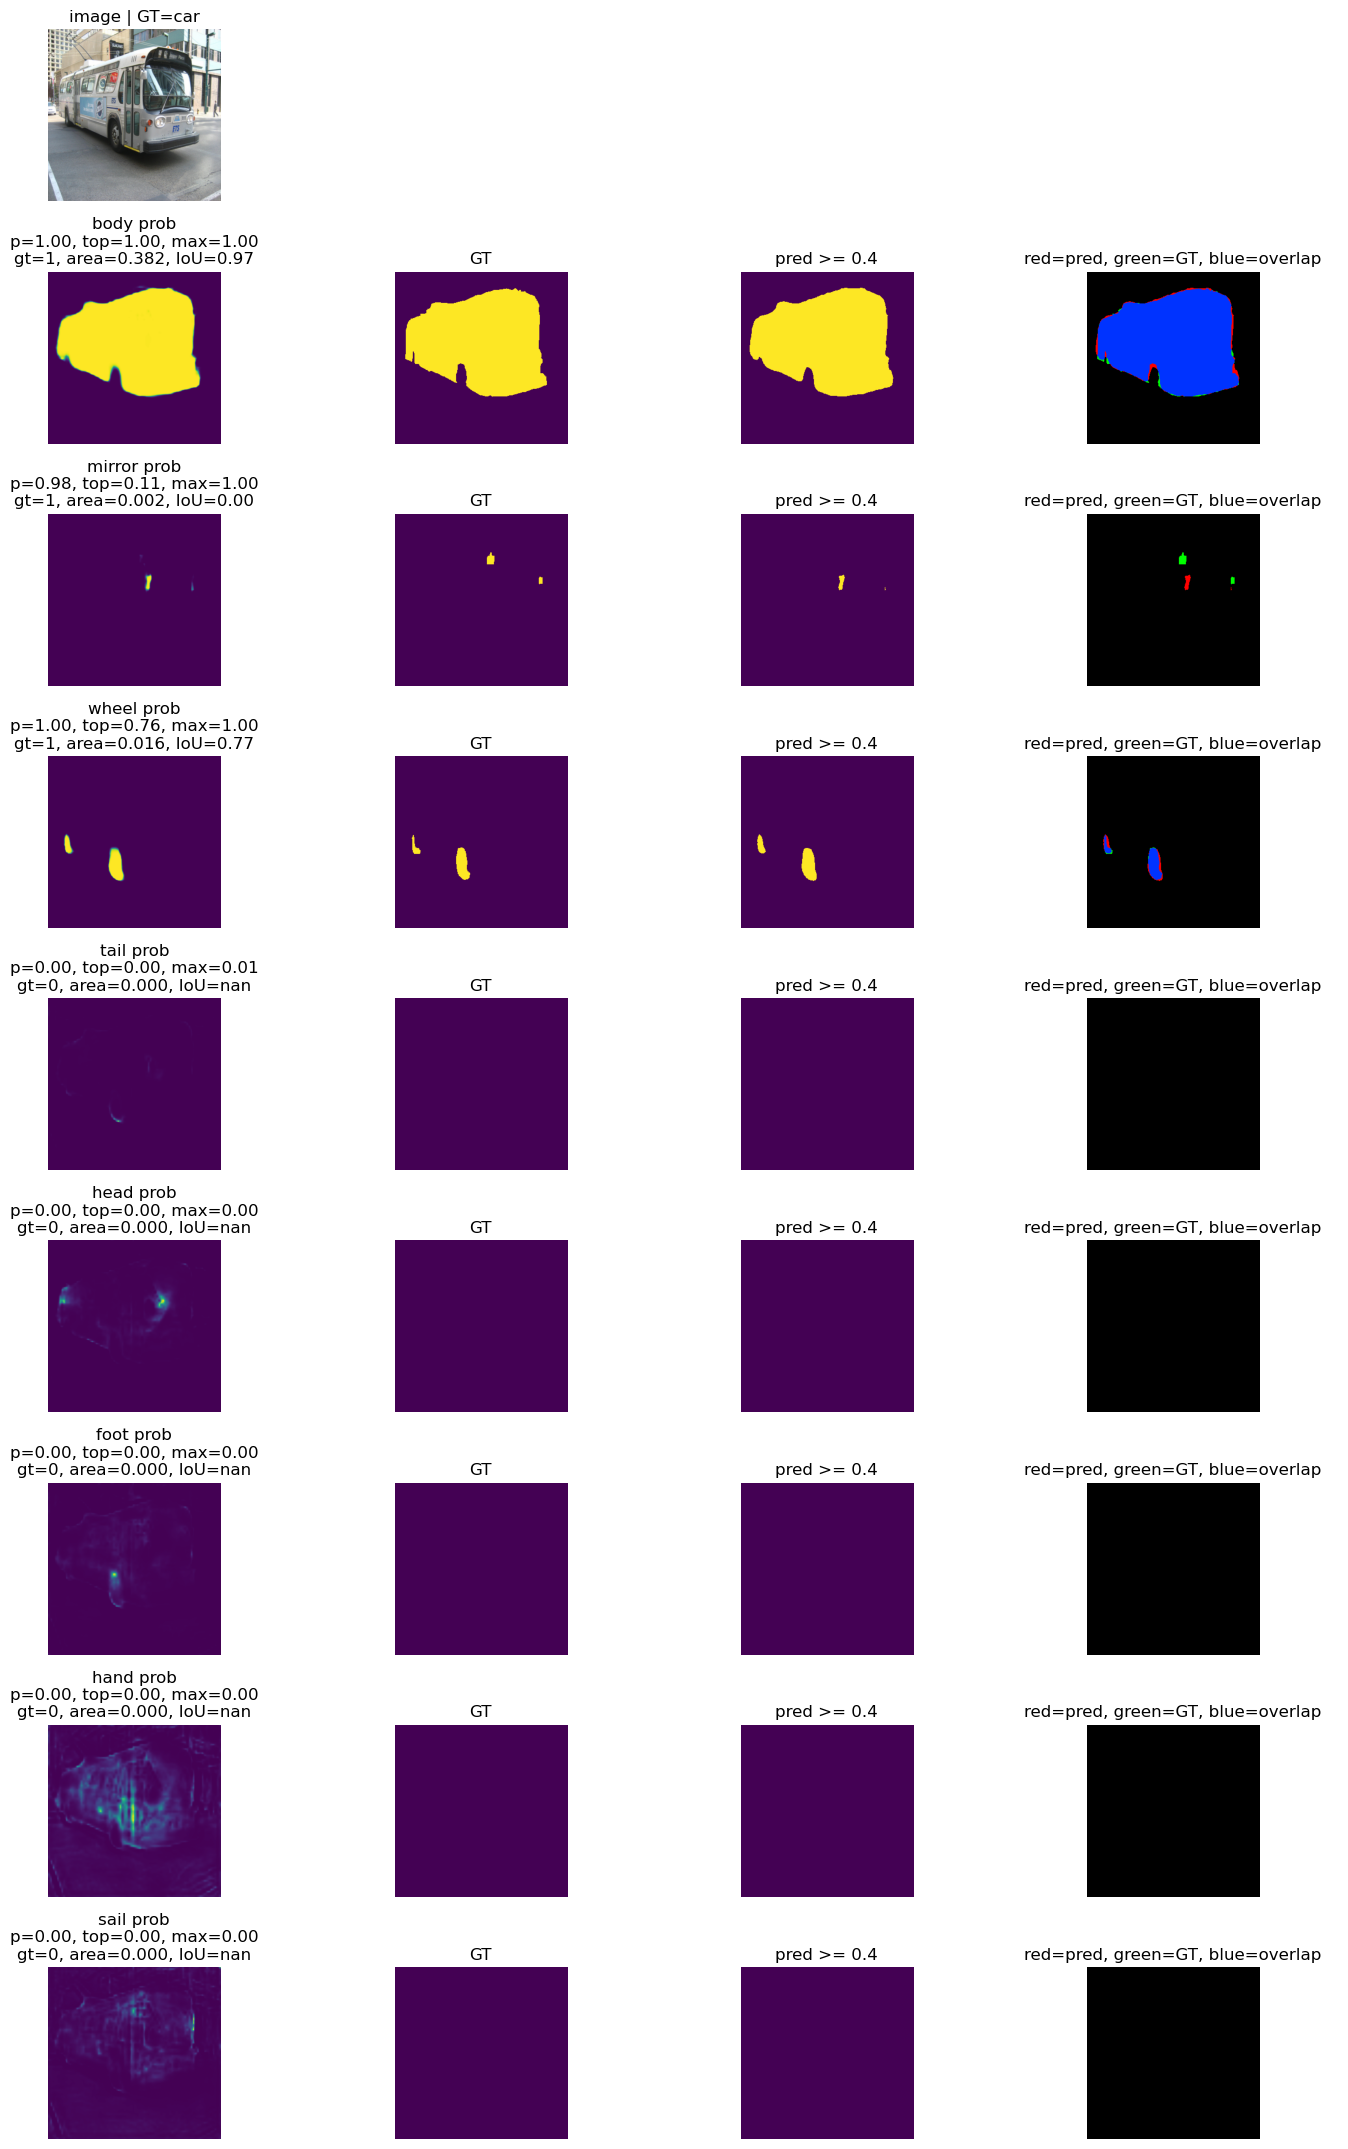

Saved figures to /home/dfli/partcat_hkg_v3/notebooks/stage1_quality_upgrade_images


In [11]:

fig = visualize_individual_part_masks(model, batch0, index=0, top_parts=8, thr=cfg.analysis.mask_bin_thr, out_path=FIG_DIR / "upgraded_individual_part_masks_sample0.png")
plt.show()
print("Saved figures to", FIG_DIR)


## 11. Presence threshold sweep

The HKG activates nodes from presence scores. A fixed threshold that is too low creates spurious nodes; too high misses real small parts. This sweep helps choose `model.stage1.presence_threshold` and `analysis.presence_tau`.


,threshold,precision,recall,f1,hallucination,miss,active_parts_mean
0,0.05,0.937500,0.937500,0.937500,0.016129,0.062500,2.666667
1,0.10,0.952000,0.929688,0.940711,0.012097,0.070312,2.604167
2,0.15,0.963115,0.917969,0.940000,0.009073,0.082031,2.541667
3,0.20,0.962810,0.910156,0.935743,0.009073,0.089844,2.520833
4,0.25,0.962500,0.902344,0.931452,0.009073,0.097656,2.500000
5,0.30,0.966527,0.902344,0.933333,0.008065,0.097656,2.489583
6,0.40,0.970085,0.886719,0.926531,0.007056,0.113281,2.437500
7,0.50,0.974249,0.886719,0.928425,0.006048,0.113281,2.427083


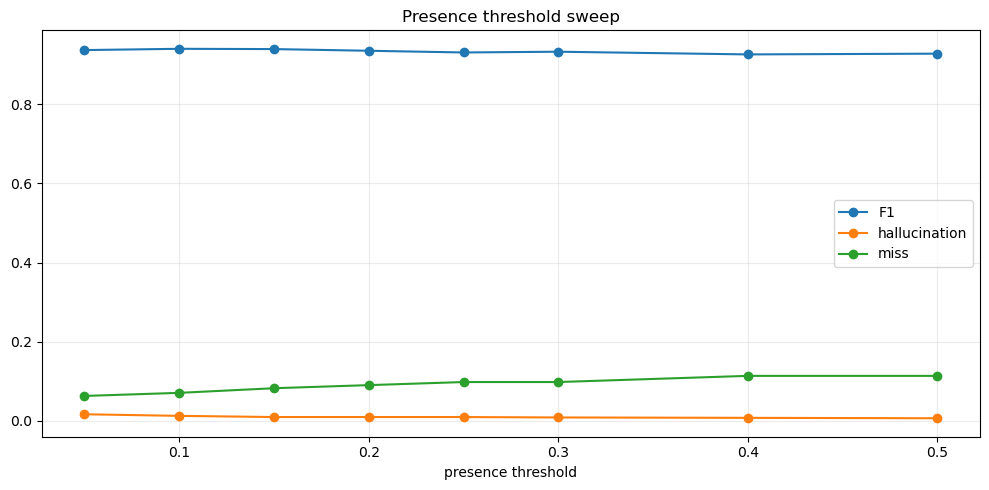

In [12]:

@torch.no_grad()
def presence_threshold_sweep(model, loader, thresholds=(0.05,0.10,0.15,0.20,0.25,0.30,0.40,0.50), max_batches=MAX_EVAL_BATCHES):
    model.eval()
    all_pred, all_gt = [], []
    for bidx, batch in enumerate(loader):
        if max_batches is not None and bidx >= int(max_batches):
            break
        out = model(batch["image"].to(DEVICE))
        all_pred.append(out["part_presence"].detach().cpu())
        all_gt.append(batch["presence"].float().cpu())
    pred = torch.cat(all_pred, 0)
    gt = torch.cat(all_gt, 0) > 0.5
    rows = []
    for t in thresholds:
        pp = pred >= t
        tp = (pp & gt).sum().item()
        fp = (pp & ~gt).sum().item()
        fn = (~pp & gt).sum().item()
        tn = (~pp & ~gt).sum().item()
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-9)
        halluc = fp / max(fp + tn, 1)
        miss = fn / max(tp + fn, 1)
        rows.append({"threshold": t, "precision": prec, "recall": rec, "f1": f1, "hallucination": halluc, "miss": miss, "active_parts_mean": float(pp.float().sum(1).mean().item())})
    return pd.DataFrame(rows)

sweep_df = presence_threshold_sweep(model, stage1_val_loader)
display(sweep_df)
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(sweep_df["threshold"], sweep_df["f1"], marker="o", label="F1")
ax.plot(sweep_df["threshold"], sweep_df["hallucination"], marker="o", label="hallucination")
ax.plot(sweep_df["threshold"], sweep_df["miss"], marker="o", label="miss")
ax.set_xlabel("presence threshold")
ax.set_title("Presence threshold sweep")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "presence_threshold_sweep.png", dpi=160, bbox_inches="tight")
plt.show()


## 12. Quality summary for HKG rebuilding

This reports which parts are likely reliable enough for prototypes. If a part has high predicted top-mean but low GT-present rate, it is a strong hallucination candidate and may contaminate HKG prototypes unless filtered/weighted.


In [13]:

quality_hint = summarize_stage1_quality_for_hkg(model, stage1_val_loader, device=DEVICE, max_batches=MAX_EVAL_BATCHES)
quality_hint_df = pd.DataFrame(quality_hint["per_part_quality_hint"])
display(quality_hint_df.sort_values("prototype_quality_hint", ascending=False))
save_json(FIG_DIR / "hkg_part_quality_hint.json", quality_hint)


,part,gt_present_rate,pred_presence_mean,pred_area_mean,pred_topmean_mean,prototype_quality_hint
0,body,1.000000,0.994922,0.279229,0.988138,1.000000
11,wheel,0.947917,0.954246,0.037898,0.777290,1.000000
6,mirror,0.718750,0.453470,0.001322,0.065013,0.079235
5,head,0.000000,0.006033,0.000028,0.001040,0.000520
1,engine,0.000000,0.005169,0.000030,0.001037,0.000519
4,hand,0.000000,0.001041,0.000061,0.000489,0.000245
8,sail,0.000000,0.001241,0.000040,0.000463,0.000231
12,wing,0.000000,0.001077,0.000023,0.000317,0.000159
3,foot,0.000000,0.000726,0.000016,0.000238,0.000119
10,tail,0.000000,0.001147,0.000010,0.000211,0.000105


## 13. Rebuild AOG-HKG using upgraded Stage 1

The builder in the audit-fixed implementation uses predicted Stage-1 evidence by default (`use_predicted_stage1_evidence=True`), which avoids the GT-template / predicted-runtime mismatch. This command creates a new HKG checkpoint from the upgraded Stage-1 checkpoint.


In [14]:

build_cmd = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "build_aog_hkg.py"),
    "--config", str(CONFIG_PATH),
    "--stage1-ckpt", str(UPGRADED_STAGE1_BEST),
    "--out", str(UPGRADED_HKG_PATH),
    "--device", "auto",
    "--num-templates-per-class", str(cfg.model.hkg.num_templates_per_class),
]
print(" ".join(build_cmd))
if RUN_HKG_REBUILD:
    subprocess.run(build_cmd, cwd=str(PROJECT_ROOT), check=True)
else:
    print("RUN_HKG_REBUILD=False, command printed only.")


/home/dfli/anaconda3/envs/partviz/bin/python /home/dfli/partcat_hkg_v3/scripts/build_aog_hkg.py --config /home/dfli/partcat_hkg_v3/configs/stage1_quality_upgrade.yaml --stage1-ckpt /home/dfli/partcat_hkg_v3/runs/stage1_quality_upgrade/checkpoints/stage1_quality_best.pt --out /home/dfli/partcat_hkg_v3/runs/stage1_quality_upgrade/checkpoints/aog_hkg_from_quality_stage1.pt --device auto --num-templates-per-class 3
RUN_HKG_REBUILD=False, command printed only.


## 14. Retrain Stage 2 from upgraded Stage 1 + upgraded HKG

After rebuilding HKG, rerun Stage 2. Then run the diagnostic notebook again and compare:

- final vs base accuracy;
- HKG-only accuracy;
- active node count;
- edge/motif contribution magnitudes;
- template residual histogram;
- selected parse visualizations.


In [15]:

stage2_cmd = [
    sys.executable,
    str(PROJECT_ROOT / "scripts" / "train_stage2_aog_hkg.py"),
    "--config", str(CONFIG_PATH),
    "--stage1-ckpt", str(UPGRADED_STAGE1_BEST),
    "--hkg", str(UPGRADED_HKG_PATH),
    "--save-dir", str(UPGRADED_STAGE2_DIR),
    "--device", "auto",
]
print(" ".join(stage2_cmd))


/home/dfli/anaconda3/envs/partviz/bin/python /home/dfli/partcat_hkg_v3/scripts/train_stage2_aog_hkg.py --config /home/dfli/partcat_hkg_v3/configs/stage1_quality_upgrade.yaml --stage1-ckpt /home/dfli/partcat_hkg_v3/runs/stage1_quality_upgrade/checkpoints/stage1_quality_best.pt --hkg /home/dfli/partcat_hkg_v3/runs/stage1_quality_upgrade/checkpoints/aog_hkg_from_quality_stage1.pt --save-dir /home/dfli/partcat_hkg_v3/runs/stage2_aog_hkg_from_quality_stage1 --device auto


## 15. Expected interpretation after the upgraded Stage 1

A good Stage-1 upgrade should show:

- higher present-part mIoU / Dice;
- lower hallucination rate for fragile parts (`head`, `foot`, `tail`, `wing`, `seat`, `engine`, `mirror`, etc.);
- lower support leak on difficult small-object/background examples;
- fewer spurious active HKG nodes;
- relation residual histogram with fewer large outliers after HKG rebuild;
- edge/motif contributions that are nonzero for structurally clear classes.

If recognition accuracy does not improve but masks improve, that is still useful: it means the HKG prototype/template construction is now receiving better evidence, and the next bottleneck is role/instance splitting rather than segmentation quality.
